### Step 1: Import Libraries and Load Image

First, we'll import the necessary libraries, `cv2` for image processing and `numpy` for numerical operations. Then, we'll load an image. You'll need to replace `'path/to/your/metal_surface_image.jpg'` with the actual path to your image file.

Upload an image


Saving scrate2.jpg to scrate2.jpg
Original Image


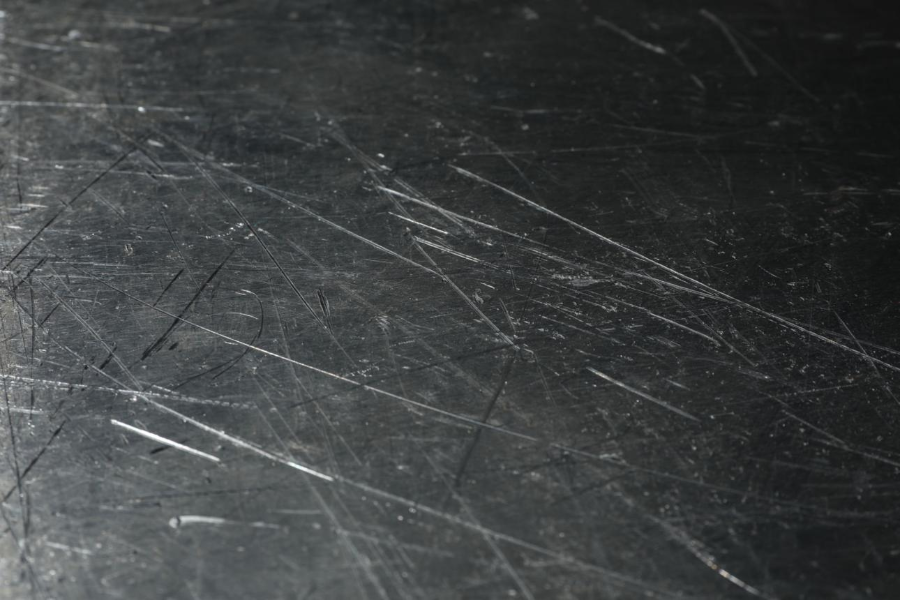

In [17]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files

print("Upload an image")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

image = cv2.imread(filename)

if image is None:
    raise Exception("Unable to read image.")

# Resize if image is too large
max_width = 900
if image.shape[1] > max_width:
    ratio = max_width / image.shape[1]
    image = cv2.resize(
        image,
        (int(image.shape[1]*ratio), int(image.shape[0]*ratio))
    )

print("Original Image")
cv2_imshow(image)

### Step 2: Grayscale Conversion and Noise Reduction

Many image processing techniques work best on grayscale images. We'll convert the loaded image to grayscale. Then, we'll apply a Gaussian blur to reduce noise, which can interfere with subsequent steps like edge detection.

Grayscale


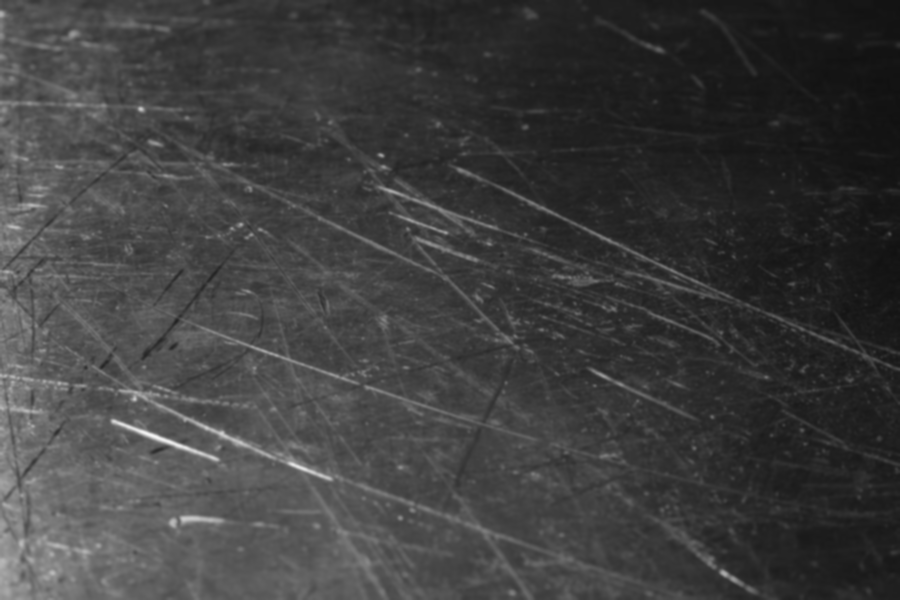

In [18]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Better denoising
gray = cv2.GaussianBlur(gray, (5,5), 0)

print("Grayscale")
cv2_imshow(gray)

### Step 3: Edge Detection (Canny)

Edge detection helps identify boundaries of objects or regions within an image. The Canny edge detector is a popular choice due to its effectiveness. We'll apply it to the blurred grayscale image.

Edges


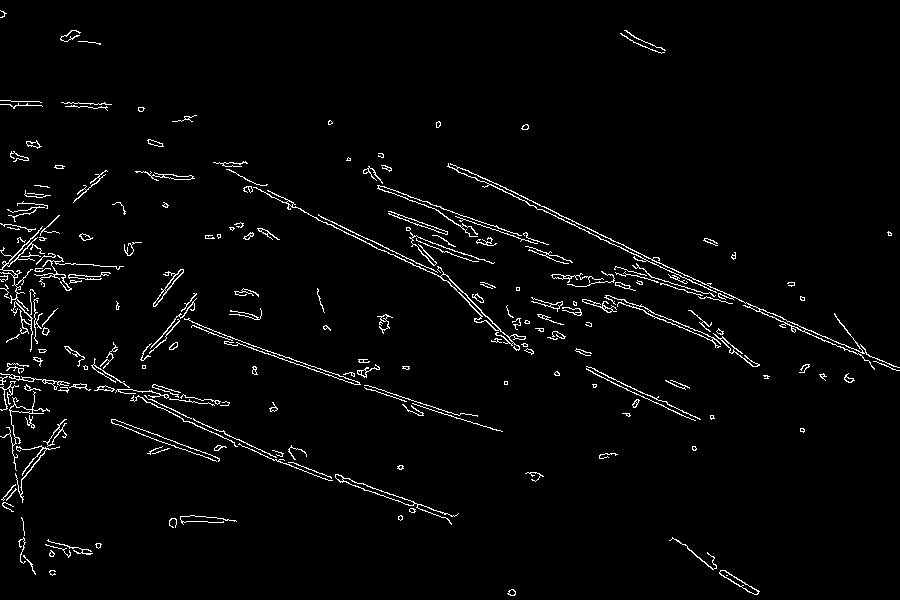

In [19]:
low = 50
high = 150

edges = cv2.Canny(gray, low, high)

print("Edges")
cv2_imshow(edges)

### Step 4: Thresholding for Segmentation

Thresholding is used to segment an image into foreground and background, often used to isolate defects. Adaptive thresholding is useful as it calculates a threshold for small regions of the image, making it more robust to varying lighting conditions.

Threshold


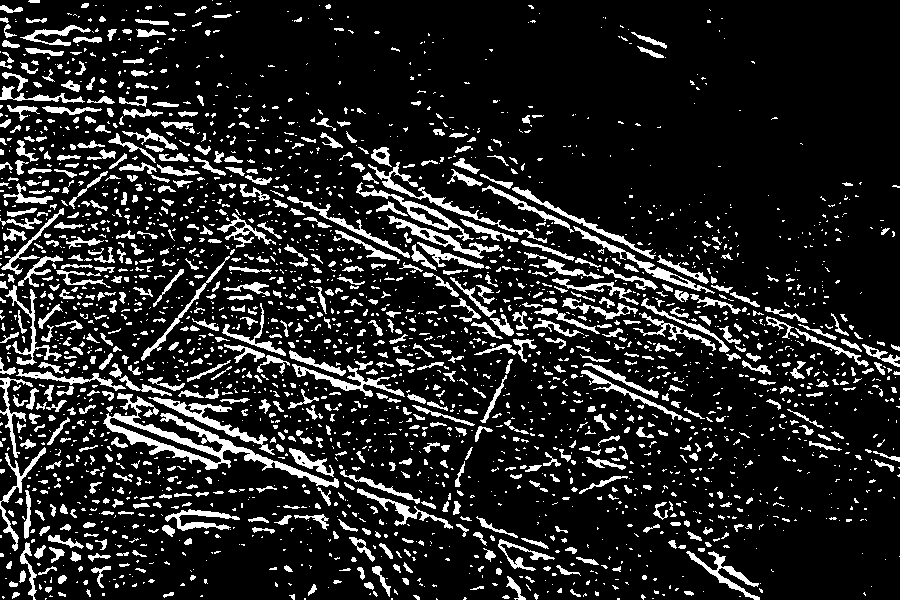

In [20]:
thresh = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    21,
    5
)

print("Threshold")
cv2_imshow(thresh)

### Step 5: Morphological Operations

Morphological operations like dilation and erosion are used to refine the shapes of objects in a binary image.

*   **Dilation**: Expands the white regions, helping to connect broken segments of a defect.
*   **Erosion**: Shrinks white regions, which can remove small noise or separate connected components.
*   **Opening (Erosion then Dilation)**: Useful for removing small objects (noise) from the foreground.
*   **Closing (Dilation then Erosion)**: Useful for closing small holes inside foreground objects or connecting nearby parts of the same object.

We'll apply a `closing` operation to fill small gaps in potential defects.

Morphology


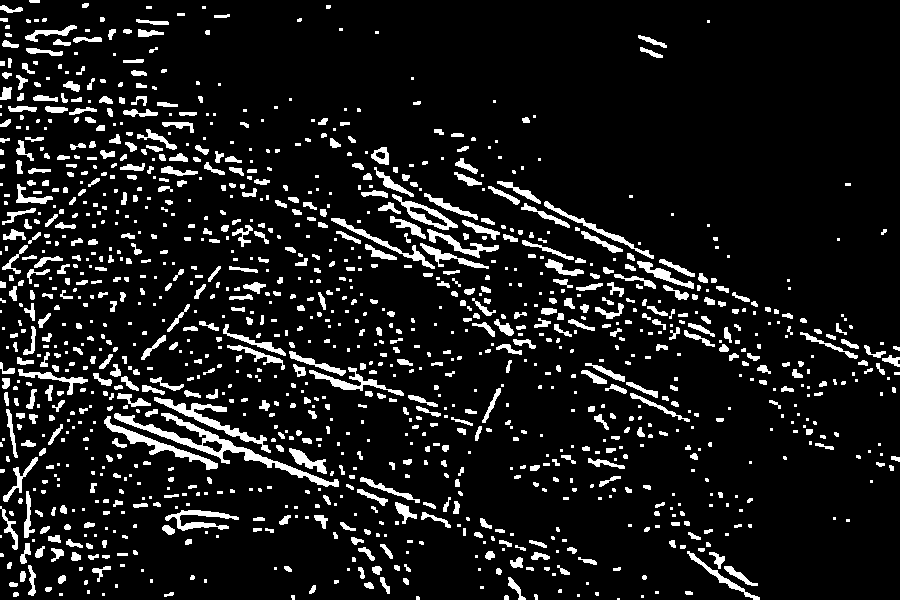

In [21]:
kernel = np.ones((3,3), np.uint8)

opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

print("Morphology")
cv2_imshow(closing)

### Step 6: Contour Extraction and Visualization

Finally, we'll find contours in the processed image. Contours are curves joining all continuous points (along the boundary), having the same color or intensity. These contours can represent the outlines of the defects. We'll then draw these contours on the original image to visualize the detected defects.

Detected Objects


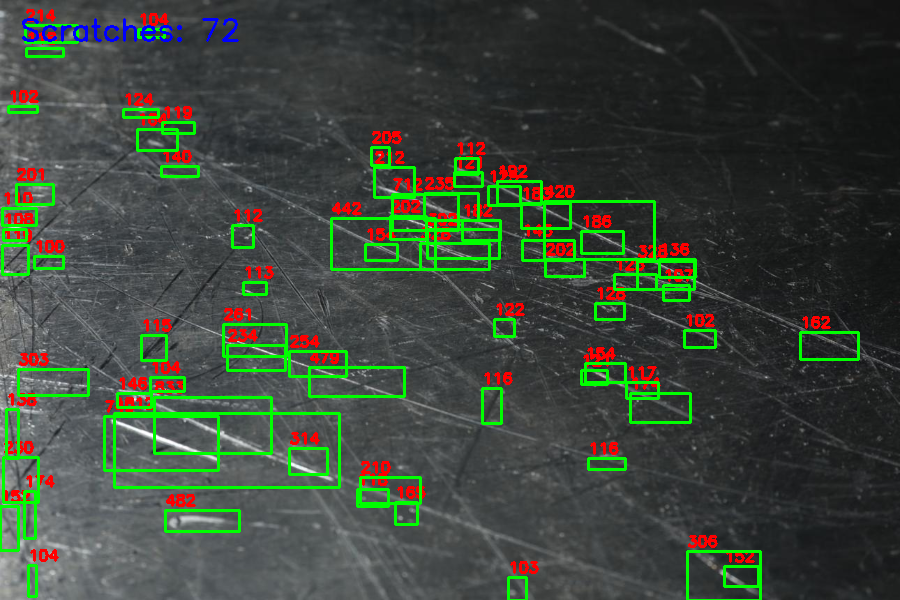

In [22]:
contours, _ = cv2.findContours(
    closing,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

output = image.copy()

count = 0

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area > 100:

        count += 1

        x,y,w,h = cv2.boundingRect(cnt)

        cv2.rectangle(output,(x,y),(x+w,y+h),(0,255,0),2)

        cv2.putText(
            output,
            f"{area:.0f}",
            (x,y-5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0,0,255),
            2
        )

cv2.putText(
    output,
    f"Scratches: {count}",
    (20,40),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (255,0,0),
    2
)

print("Detected Objects")
cv2_imshow(output)

In [16]:
cv2.imwrite("processed_result.png", output)

files.download("processed_result.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>